In [1]:
# Figure 3: generality / the filtering-series test (Claim 3), plus the regulon's own
# GO-term enrichment profile. Panel A: Soo's 61 genes are the intersection of three
# ATFS-1-activating conditions - nuo-6, spg-7(RNAi), and atfs-1(et15)-and-(et17)-
# combined - does the shortage of folding machinery among them reflect ATFS-1
# biology, or is the AND filter itself manufacturing it? Walk the same question back
# through the looser lists the 61 were carved out of. If the artifact hypothesis
# were right, folding representation would fall as the filter tightens. Panel B: a
# separate question - across every annotated GO term, which are over- or under-
# represented in the fixed 61-gene regulon against the expressed background? Re-
# derives Analysis A's filtering-series walk (its cells 0-3 and 6) and its GO-term
# enrichment test (its cells 4-5) independently rather than reading a stored
# intermediate, and validates both against the exact numbers already established
# before drawing anything.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import gzip
import pandas as pd
import numpy as np
from scipy.stats import hypergeom
import matplotlib.pyplot as plt
from figure_style import BLUE, ORANGE, GREEN, GREY, INK, FULL_W, THREEQ_W, panel_label, save

OBO = "ref_data/go/go-basic.obo"
terms, alt_id_map = {}, {}
cur = None

def _store(term):
    if term and term["id"]:
        terms[term["id"]] = term

with open(OBO) as fh:
    for line in fh:
        line = line.rstrip("\n")
        if line.startswith("["):
            _store(cur)
            cur = {"id": None, "name": None, "ns": None, "parents": set(),
                   "obsolete": False} if line == "[Term]" else None
            continue
        if cur is None or not line:
            continue
        key, _, val = line.partition(": ")
        if key == "id":
            cur["id"] = val
        elif key == "name":
            cur["name"] = val
        elif key == "namespace":
            cur["ns"] = val
        elif key == "alt_id":
            alt_id_map[val] = cur["id"]
        elif key == "is_obsolete" and val == "true":
            cur["obsolete"] = True
        elif key == "is_a":
            cur["parents"].add(val.split(" ! ")[0].strip())
        elif key == "relationship" and val.startswith("part_of "):
            cur["parents"].add(val.split()[1])
_store(cur)

_ancestor_cache = {}
def ancestors(term_id):
    if term_id in _ancestor_cache:
        return _ancestor_cache[term_id]
    _ancestor_cache[term_id] = set()
    found = set()
    for parent in terms.get(term_id, {}).get("parents", ()):
        if parent in terms:
            found.add(parent)
            found |= ancestors(parent)
    _ancestor_cache[term_id] = found
    return found

print(f"GO ontology: {len(terms):,} terms parsed")

GO ontology: 48,340 terms parsed


In [2]:
# Annotations, propagated, exactly as in analysis_a.ipynb.
GAF = "ref_data/go/wb.gaf.gz"
records = []
with gzip.open(GAF, "rt") as fh:
    for line in fh:
        if line.startswith("!"):
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 15 or f[12] != "taxon:6239":
            continue
        records.append((f[1], f[3], f[4], f[6], f[8]))
gaf = pd.DataFrame(records, columns=["gid", "qualifier", "go_id", "evidence", "aspect"])
gaf = gaf[~gaf["qualifier"].str.startswith("NOT") & (gaf["evidence"] != "ND")]
gaf["go_id"] = gaf["go_id"].map(lambda t: alt_id_map.get(t, t))

gene_terms = {}
for gid, go_id in zip(gaf["gid"], gaf["go_id"]):
    if go_id not in terms or terms[go_id]["obsolete"]:
        continue
    gene_terms.setdefault(gid, set()).add(go_id)
    gene_terms[gid] |= ancestors(go_id)

term_genes = {}
for gid, tset in gene_terms.items():
    for term in tset:
        term_genes.setdefault(term, set()).add(gid)

CPM = "ref_data/GSE110984/GSE110984_normalized_filtered_CPM_table_VANJ_20171130.txt.gz"
expressed = set(pd.read_csv(CPM, sep="\t")["ens_gene"].dropna())
background = expressed & set(gene_terms)
print(f"Expressed background: {len(expressed):,} genes, {len(background):,} annotated")

Expressed background: 13,837 genes, 9,371 annotated


In [3]:
# The four gene sets, same nesting logic as analysis_a.ipynb: loosest (one
# condition) to strictest (Soo's 61, all three conditions plus Soo's own further
# filtering beyond the plain intersection). The third condition is spg-7(RNAi)
# ATFS-1-dependence (Nargund 2012 Table S3), not a third Wu 2018 sheet - see
# analysis_a.ipynb cell 3 for the source-paper quote this is built from.
ids = pd.read_csv("ref_data/c_elegans.PRJNA13758.WS285.geneIDs.txt.gz", header=None,
                  names=["taxon", "gid", "public_name", "seqname", "status", "biotype"])
seq_to_gid = {str(s).lower(): g for s, g in zip(ids["seqname"], ids["gid"]) if pd.notna(s)}
name_to_gid = {str(n).lower(): g for g, n in zip(ids["gid"], ids["public_name"]) if pd.notna(n)}

soo = pd.read_excel("data/raw/ATFS1_targets_Soo.xlsx", sheet_name="Sheet1")
soo = soo.iloc[0:64].dropna(subset=["Gene name"]).rename(columns={"Gene sequence \nname": "seqname"})
regulon_df = soo[~soo["Gene name"].isin(["hsp-6", "hsp-60"])]
regulon = {seq_to_gid[str(s).lower()] for s in regulon_df["seqname"]}
if len(regulon) != 61:
    raise RuntimeError(f"Expected 61 regulon genes, resolved {len(regulon)}.")

WU = "data/raw/wu2018_AdditionalFile2.xlsx"
sheet = lambda name: pd.read_excel(WU, sheet_name=name, header=2)
up = lambda df: set(df[df["logFC"] > 0]["ens_gene"])
nuo6_dependent = up(sheet("nuo-6")) - up(sheet("nuo-6;atfs-1"))
et_both = up(sheet("atfs-1(et15)")) & up(sheet("atfs-1(et17)"))

# Resolution needs the same seqname-then-public-name fallback as analysis_a.ipynb
# and analysis_c.ipynb: a handful of Table S3 rows carry a gene symbol in the
# seqname column instead of a real WormBase sequence name, and resolving on
# seqname alone silently drops those genes rather than raising.
table_s3 = pd.read_excel(
    "data/raw/nargund2012_TableS3_spg7_ATFS1dependent.xlsx", sheet_name="Sheet1", header=None)
table_s3.columns = ["seqname","symbol","function","wt_fold","atfs1_fold","fold_diff","blank","pct_less","na"]
table_s3["wt_fold_numeric"] = pd.to_numeric(table_s3["wt_fold"], errors="coerce")
table_s3 = table_s3[table_s3["wt_fold_numeric"].notna()].copy()
table_s3["seqname"] = table_s3["seqname"].astype(str).str.strip()
table_s3["symbol"] = table_s3["symbol"].astype(str).str.strip()

def resolve_s3_gid(row):
    s = str(row["seqname"]).lower()
    if s in seq_to_gid:
        return seq_to_gid[s]
    if s in name_to_gid:
        return name_to_gid[s]
    sym = str(row["symbol"]).lower()
    if sym in name_to_gid:
        return name_to_gid[sym]
    if sym in seq_to_gid:
        return seq_to_gid[sym]
    return None

table_s3["gid"] = table_s3.apply(resolve_s3_gid, axis=1)
spg7_dependent = set(table_s3["gid"].dropna())

three_way = nuo6_dependent & et_both & spg7_dependent

GENE_SETS = {
    "nuo-6 dependent\n(1 condition)": nuo6_dependent,
    "et15 & et17\n(2 conditions)": et_both,
    "all three\nconditions": three_way,
    "Soo high-\nconfidence 61": regulon,
}
STAGE_LABELS = list(GENE_SETS)
sizes = [len(GENE_SETS[s]) for s in STAGE_LABELS]
EXPECTED_SIZES = [1673, 529, 67, 61]
if sizes != EXPECTED_SIZES:
    raise RuntimeError(f"Filtering-series sizes changed: got {sizes}, expected {EXPECTED_SIZES}.")
print("Filtering-series sizes validated:", dict(zip(STAGE_LABELS, sizes)))

Filtering-series sizes validated: {'nuo-6 dependent\n(1 condition)': 1673, 'et15 & et17\n(2 conditions)': 529, 'all three\nconditions': 67, 'Soo high-\nconfidence 61': 61}


/opt/homebrew/Caskroom/miniforge/base/envs/atfs1/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [4]:
# Folding-related GO category (structural: 3 current roots + all descendants, not
# a hand-picked term list - see analysis_a.ipynb for why that distinction mattered)
# and the walk function, applied to both the GO category and the Pfam census.
FOLDING_ROOTS = ["GO:0006457", "GO:0044183", "GO:0140309"]
children = {}
for term, meta in terms.items():
    for parent in meta["parents"]:
        children.setdefault(parent, set()).add(term)

def descendants(root):
    out, stack = set(), [root]
    while stack:
        for child in children.get(stack.pop(), ()):
            if child not in out:
                out.add(child)
                stack.append(child)
    return out

folding_terms = set(FOLDING_ROOTS) | {d for r in FOLDING_ROOTS for d in descendants(r)}
folding_terms = {t for t in folding_terms if not terms[t]["obsolete"]}
folding_genes = set().union(*(term_genes.get(t, set()) for t in folding_terms))

census = pd.read_csv("data/chaperone_protease_census.csv")
census_gids = {seq_to_gid[str(s).lower()] for s in census["seqname"] if str(s).lower() in seq_to_gid}

def walk_category(category_genes, universe, sets):
    out = []
    K = len(category_genes & universe)
    for label, genes in sets.items():
        q = genes & universe
        k = len(category_genes & q)
        exp = K * len(q) / len(universe)
        out.append({"stage": label, "tested": len(q), "obs": k, "exp": exp,
                    "pct": 100 * k / len(q), "fold": k / exp if exp else np.nan,
                    "p": hypergeom.sf(k - 1, len(universe), K, len(q))})
    return pd.DataFrame(out)

go_walk = walk_category(folding_genes, background, GENE_SETS)
census_walk = walk_category(census_gids, expressed, GENE_SETS)

print("--- GO folding-related ---")
print(go_walk.to_string(index=False, float_format=lambda x: f"{x:.3g}"))
print("\n--- Pfam census ---")
print(census_walk.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

EXPECTED_GO_PCT = [0.74, 1.53, 2.08, 2.38]
EXPECTED_CENSUS_PCT = [0.72, 0.76, 2.99, 3.28]
for got, exp, label in [(go_walk["pct"].round(2).tolist(), EXPECTED_GO_PCT, "GO"),
                         (census_walk["pct"].round(2).tolist(), EXPECTED_CENSUS_PCT, "census")]:
    if got != exp:
        raise RuntimeError(f"{label} walk percentages changed: got {got}, expected {exp}.")
print("\nBoth walks validated against the pre-registered expected values exactly.")

--- GO folding-related ---
                         stage  tested  obs   exp   pct  fold     p
nuo-6 dependent\n(1 condition)    1085    8  13.9 0.737 0.576 0.974
   et15 & et17\n(2 conditions)     262    4  3.36  1.53  1.19 0.433
         all three\nconditions      48    1 0.615  2.08  1.63 0.462
      Soo high-\nconfidence 61      42    1 0.538  2.38  1.86 0.419

--- Pfam census ---
                         stage  tested  obs   exp   pct  fold      p
nuo-6 dependent\n(1 condition)    1673   12   8.1 0.717  1.48  0.105
   et15 & et17\n(2 conditions)     529    4  2.56 0.756  1.56  0.253
         all three\nconditions      67    2 0.324  2.99  6.16 0.0417
      Soo high-\nconfidence 61      61    2 0.295  3.28  6.77 0.0352

Both walks validated against the pre-registered expected values exactly.


In [5]:
# GO-term enrichment test for Panel B: the fixed 61-gene regulon against the same
# expressed background used above - a separate question from the filtering-series
# walk, not another view of its four points. Re-derives analysis_a.ipynb's cells
# 4-5 exactly: terms tested only where they cover 5-1,000 background genes (below
# that nothing survives correction, above it a term is too generic to mean
# anything), both tails via the hypergeometric distribution, corrected across all
# tested terms with Benjamini-Hochberg.
from statsmodels.stats.multitest import multipletests

MIN_TERM, MAX_TERM = 5, 1000

def enrichment(query, bg):
    q = set(query) & bg
    rows = []
    for term, annotated in term_genes.items():
        K = len(annotated & bg)
        if not (MIN_TERM <= K <= MAX_TERM):
            continue
        k = len(annotated & q)
        rows.append((term, terms[term]["name"], terms[term]["ns"], k, len(q), K, len(bg),
                     hypergeom.sf(k - 1, len(bg), K, len(q)),
                     hypergeom.cdf(k, len(bg), K, len(q))))
    out = pd.DataFrame(rows, columns=["go_id", "term", "namespace", "k", "n", "K", "N",
                                      "p_enrich", "p_deplete"])
    for tail in ("enrich", "deplete"):
        out[f"fdr_{tail}"] = multipletests(out[f"p_{tail}"], method="fdr_bh")[1]
    out["expected"] = out["K"] * out["n"] / out["N"]
    out["fold"] = out["k"] / out["expected"].replace(0, np.nan)
    return out.sort_values(["p_enrich", "go_id"])

regulon_go = enrichment(regulon, background)

top_term = regulon_go.iloc[0]
if (top_term["term"], int(top_term["k"]), round(top_term["fold"], 1), round(top_term["fdr_enrich"], 4)) \
        != ("glucuronosyltransferase activity", 5, 17.2, 0.0411):
    raise RuntimeError(f"Top enriched term changed: got {top_term[['term', 'k', 'fold', 'fdr_enrich']].tolist()}.")

mito = regulon_go[regulon_go["term"] == "mitochondrion"].iloc[0]
if (int(mito["k"]), round(mito["fold"], 2), round(mito["fdr_enrich"], 3)) != (10, 2.86, 0.571):
    raise RuntimeError(f"mitochondrion row changed: got {mito[['k', 'fold', 'fdr_enrich']].tolist()}.")

n_sig_enrich = int((regulon_go["fdr_enrich"] < 0.05).sum())
n_sig_deplete = int((regulon_go["fdr_deplete"] < 0.05).sum())
if (n_sig_enrich, n_sig_deplete) != (1, 0):
    raise RuntimeError(f"Significance counts changed: {n_sig_enrich} enriched, "
                       f"{n_sig_deplete} depleted - expected (1, 0).")

print(f"GO enrichment validated against analysis_a.ipynb: {n_sig_enrich} term reaches "
      f"FDR < 0.05 (glucuronosyltransferase activity, {int(top_term['k'])} genes, "
      f"{top_term['fold']:.1f}x, FDR={top_term['fdr_enrich']:.4f}), {n_sig_deplete} depleted.")
print(f"mitochondrion (not significant): {int(mito['k'])} genes, {mito['fold']:.2f}x, "
      f"FDR = {mito['fdr_enrich']:.3f}.")

GO enrichment validated against analysis_a.ipynb: 1 term reaches FDR < 0.05 (glucuronosyltransferase activity, 5 genes, 17.2x, FDR=0.0411), 0 depleted.
mitochondrion (not significant): 10 genes, 2.86x, FDR = 0.571.


Saved figures/figure3_filtering_series.{pdf,svg,png}


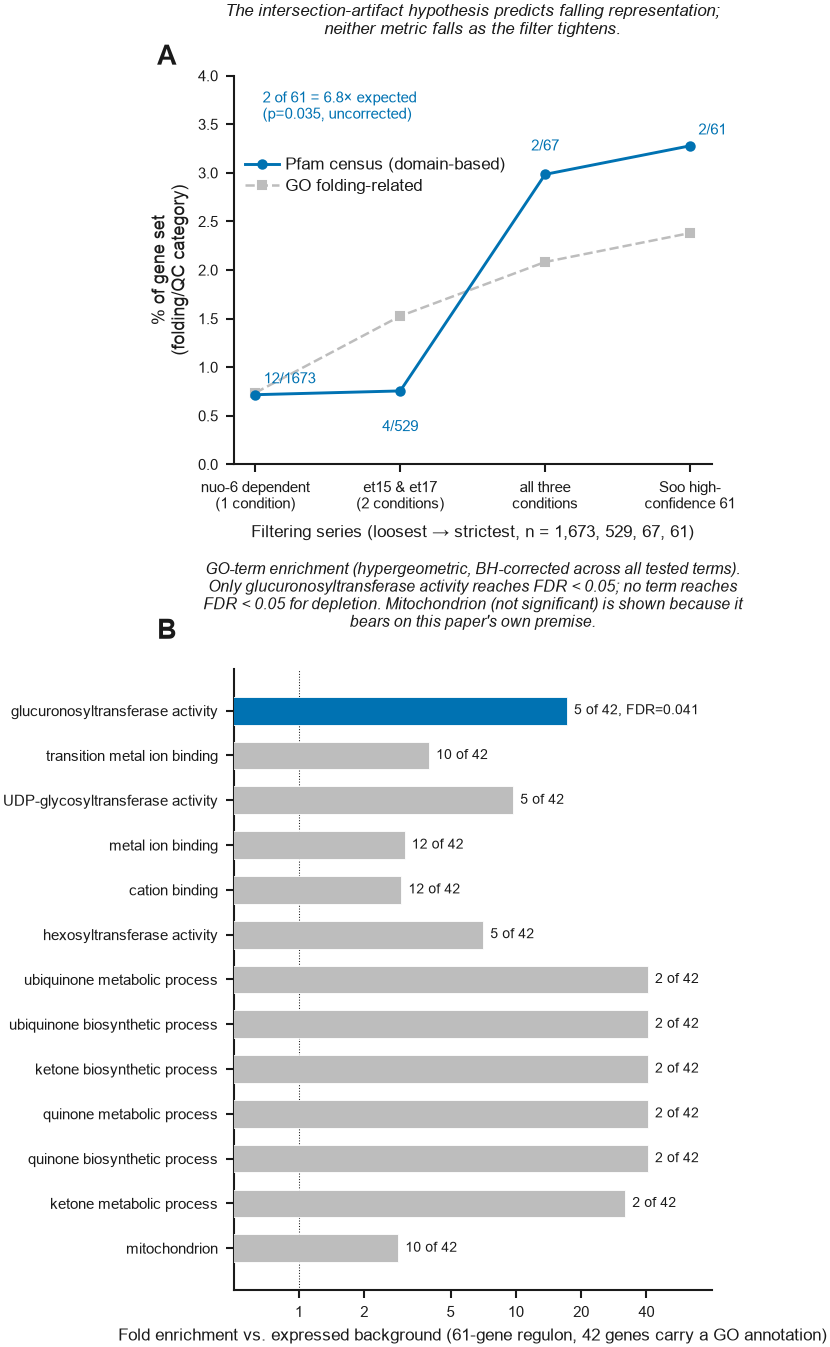

In [6]:
# Draw. Panel A: % of each filter stage that is folding-related, both metrics -
# Pfam census (primary, domain-based, independent of GO) rises monotonically;
# GO folding-related (secondary) moves within noise rather than falling. Either
# reading rejects the intersection-artifact hypothesis, which predicted a fall.
# Panel B: GO-term enrichment on the fixed 61-gene regulon against the expressed
# background - a separate analysis from Panel A's filtering-series walk, not
# another view of the same four points. Top 13 terms by raw p-value (mechanical
# cutoff, not curated): the minimum that includes every term this notebook's own
# validated numbers single out - glucuronosyltransferase activity (the one term
# reaching FDR < 0.05) and mitochondrion (not significant, shown anyway because it
# bears directly on this paper's own premise about mitochondrial import failure,
# and a reader would otherwise wonder why it is missing).
x = np.arange(len(STAGE_LABELS))
fig, axes = plt.subplots(2, 1, figsize=(THREEQ_W, THREEQ_W * 1.8),
                         gridspec_kw={"height_ratios": [1, 1.6]})

ax = axes[0]
ax.plot(x, census_walk["pct"], "-o", color=BLUE, ms=4, lw=1.4, zorder=3, label="Pfam census (domain-based)")
ax.plot(x, go_walk["pct"], "--s", color=GREY, ms=3.5, lw=1.2, zorder=2, label="GO folding-related")
# Label placement is chosen per point to dodge that point's own connecting
# line segments, not a fixed corner. Correcting the spg-7(RNAi) omission moved
# point 2 from 1.30% to 2.99% - much closer to point 3 (3.28%) than before - which
# put the old upper-right default for point 1 directly on its now-steep outgoing
# segment, and the old lower-left default for point 2 directly on its now-steep
# incoming segment. Both caught by inspecting the re-rendered figure, not by
# anything the code itself flagged.
N_LABEL_OFFSETS = {0: (4, 4), 1: (0, -14), 2: (0, 10), 3: (4, 4)}
N_LABEL_HA = {0: "left", 1: "center", 2: "center", 3: "left"}
N_LABEL_VA = {0: "bottom", 1: "top", 2: "bottom", 3: "bottom"}
for xi, row in census_walk.iterrows():
    ax.annotate(f"{row['obs']:.0f}/{row['tested']:.0f}", (xi, row["pct"]),
                textcoords="offset points", xytext=N_LABEL_OFFSETS[xi],
                ha=N_LABEL_HA[xi], va=N_LABEL_VA[xi], fontsize=7, color=BLUE)
# Placed top-left rather than top-center: the title above is centered on the full
# axis width, and the "2/67"/"2/61" point labels sit in the upper-right around
# y=3.0-3.4, so the only corner clear of both is the top-left, well above the
# loose-end points (12/1673, 4/529) sitting near y=0.7-1.5.
ax.text(0.05, 3.85, "2 of 61 = 6.8× expected\n(p=0.035, uncorrected)",
        ha="left", va="top", fontsize=7, color=BLUE)
ax.set_ylabel("% of gene set\n(folding/QC category)", fontsize=8.5)
ax.set_ylim(0, 4.0)
ax.set_xticks(x)
ax.set_xticklabels(STAGE_LABELS, fontsize=8)
ax.set_xlabel("Filtering series (loosest → strictest, n = " +
              ", ".join(f"{int(t):,}" for t in census_walk["tested"]) + ")", fontsize=8, labelpad=6)
ax.set_title("The intersection-artifact hypothesis predicts falling representation;\n"
             "neither metric falls as the filter tightens.",
             fontsize=8, style="italic", color=INK, pad=20)
panel_label(ax, "A")
ax.legend(loc="upper left", frameon=False, fontsize=8, handletextpad=0.4,
          bbox_to_anchor=(0.0, 0.82), bbox_transform=ax.transAxes)

ax2 = axes[1]
top = regulon_go.head(13).reset_index(drop=True)
bar_colors = [BLUE if fdr < 0.05 else GREY for fdr in top["fdr_enrich"]]
y = np.arange(len(top))
ax2.axvline(1, color=INK, lw=0.5, ls=":", zorder=1)
ax2.barh(y, top["fold"], color=bar_colors, height=0.62, edgecolor="white", linewidth=0.4, zorder=3)
for yi, row in top.iterrows():
    label = (f"{int(row['k'])} of {int(row['n'])}, FDR={row['fdr_enrich']:.3f}"
             if row["fdr_enrich"] < 0.05 else f"{int(row['k'])} of {int(row['n'])}")
    ax2.text(row["fold"] * 1.08, yi, label, va="center", fontsize=6.5, color=INK)
ax2.set_yticks(y)
ax2.set_yticklabels(top["term"], fontsize=7.5)
ax2.invert_yaxis()
ax2.set_xscale("log")
ax2.set_xlim(0.5, 80)
ax2.set_xticks([1, 2, 5, 10, 20, 40])
ax2.set_xticklabels(["1", "2", "5", "10", "20", "40"])
ax2.minorticks_off()
ax2.set_xlabel(f"Fold enrichment vs. expressed background "
               f"(61-gene regulon, {int(top['n'].iloc[0])} genes carry a GO annotation)", fontsize=8)
ax2.set_title("GO-term enrichment (hypergeometric, BH-corrected across all tested terms).\n"
              "Only glucuronosyltransferase activity reaches FDR < 0.05; no term reaches\n"
              "FDR < 0.05 for depletion. Mitochondrion (not significant) is shown because it\n"
              "bears on this paper's own premise.",
              fontsize=7.5, style="italic", color=INK, pad=20)
panel_label(ax2, "B")

for a in axes:
    a.tick_params(labelsize=7)
    for spine in ("top", "right"):
        a.spines[spine].set_visible(False)

fig.tight_layout()
save(fig, "figure3_filtering_series")
plt.show()